In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="darkgrid")

# Load data
data = pd.read_csv("Linhac24-25_Sportlogiq.csv")

print(data.isnull().sum())
data.head(10)

gameid                                0
opposingteamgoalieoniceid          3266
opposingteamid                        0
playerid                              0
teamgoalieoniceid                  7080
teamid                                0
teaminpossession                  73890
currentpossession                 73890
xg_allattempts                   525454
compiledgametime                      0
eventname                             0
ishomegame                            0
manpowersituation                     0
opposingteamskatersonicecount         0
outcome                               0
period                                0
playerprimaryposition                 0
scoredifferential                     0
teamskatersonicecount                 0
type                                  0
xadjcoord                             0
yadjcoord                             0
dtype: int64


,gameid,opposingteamgoalieoniceid,opposingteamid,playerid,teamgoalieoniceid,teamid,teaminpossession,currentpossession,xg_allattempts,compiledgametime,...,manpowersituation,opposingteamskatersonicecount,outcome,period,playerprimaryposition,scoredifferential,teamskatersonicecount,type,xadjcoord,yadjcoord
0,72393,553243.0,885,489917,172367.0,814,NaN,NaN,NaN,0.000000,...,evenStrength,5,failed,1,F,0,5,none,0.304306,0.251442
1,72393,172367.0,814,435025,553243.0,885,NaN,NaN,NaN,0.000000,...,evenStrength,5,successful,1,F,0,5,recovered,-0.304306,-0.251442
2,72393,172367.0,814,435025,553243.0,885,885.0,0.0,NaN,1.333333,...,evenStrength,5,successful,1,F,0,5,faceoffcontested,0.205826,0.245975
3,72393,553243.0,885,489917,172367.0,814,885.0,0.0,NaN,1.333333,...,evenStrength,5,failed,1,F,0,5,contested,-0.205826,-0.245975
4,72393,172367.0,814,435025,553243.0,885,885.0,0.0,NaN,2.166667,...,evenStrength,5,successful,1,F,0,5,south,3.223473,3.766563
5,72393,172367.0,814,706220,553243.0,885,885.0,0.0,NaN,2.966667,...,evenStrength,5,successful,1,D,0,5,regular,-19.911827,11.310680
6,72393,172367.0,814,706220,553243.0,885,885.0,0.0,NaN,4.466667,...,evenStrength,5,failed,1,D,0,5,north,-7.338295,26.398914
7,72393,553243.0,885,213380,172367.0,814,885.0,0.0,NaN,4.700000,...,evenStrength,5,successful,1,F,0,5,pass,1.813835,-24.897058
8,72393,553243.0,885,213380,172367.0,814,814.0,1.0,NaN,6.033333,...,evenStrength,5,successful,1,F,0,5,none,-17.800873,-40.991177
9,72393,553243.0,885,213380,172367.0,814,814.0,1.0,NaN,6.533333,...,evenStrength,5,successful,1,F,0,5,body,-16.794991,-40.488235


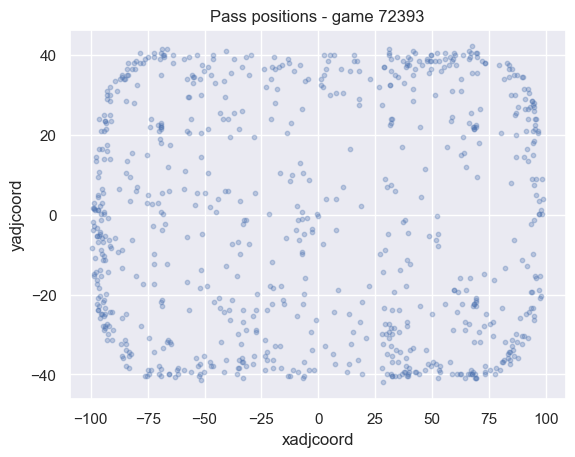

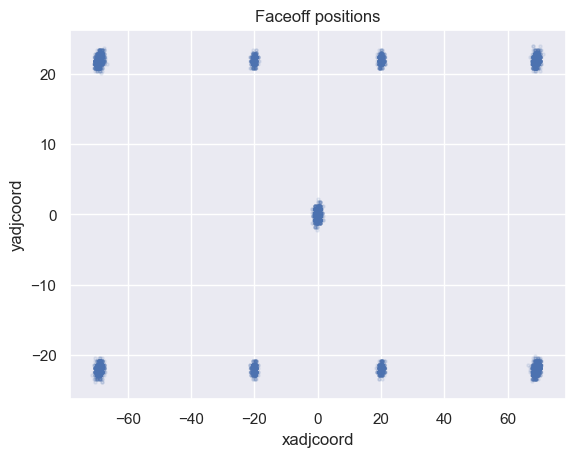

In [3]:
# Plot passes
passes = data[(data['eventname'] == 'pass') & (data['gameid'] == 72393)]
plt.scatter(passes['xadjcoord'], passes['yadjcoord'], alpha=0.3, s=10)
plt.title('Pass positions - game 72393')
plt.xlabel('xadjcoord')
plt.ylabel('yadjcoord')
plt.show()

# Plot faceoffs
faceoffs = data[data['eventname'] == 'faceoff']
plt.scatter(faceoffs['xadjcoord'], faceoffs['yadjcoord'], alpha=0.1, s=5)
plt.title('Faceoff positions')
plt.xlabel('xadjcoord')
plt.ylabel('yadjcoord')
plt.show()

In [4]:
# All controlled entries to the offensive zone and entry types
data[data['eventname'] == 'controlledentry']['type'].value_counts()

# All events with more than 80% probability of being a goal
data[data['xg_allattempts'] > 0.8][['eventname', 'xg_allattempts', 'xadjcoord', 'yadjcoord']]

,eventname,xg_allattempts,xadjcoord,yadjcoord
53328,shot,0.810006,-58.539108,38.976471
313148,shot,0.949455,-90.331482,-30.929413
326988,shot,0.882324,82.177345,-3.267647
399178,shot,0.805608,-40.032639,-40.485291
437140,shot,0.805782,-82.284424,37.973530
496175,shot,0.896192,84.692047,1.258823
538756,shot,0.809618,85.805008,-1.761765


## Optimal number of passes during powerplay

In [5]:
# Number of passes from start of powerplay to goal
num_passes = []
total_pp_seqs = 0

for game, game_df in data.groupby('gameid'):
    game_df = game_df.sort_values('compiledgametime').reset_index(drop=True)
    
    # Filter to only powerplay events
    pp_only = game_df[game_df['manpowersituation'] == 'powerPlay'].copy().reset_index(drop=True)
    
    if len(pp_only) == 0:
        continue
    
    # New powerplay if 10 seconds gap, after a goal, or after a faceoff
    pp_only['time_gap'] = pp_only['compiledgametime'].diff()
    pp_only['prev_was_goal'] = pp_only['eventname'].shift(1) == 'goal'
    pp_only['prev_was_faceoff'] = pp_only['eventname'].shift(1) == 'faceoff'
    pp_only['pp_start'] = (pp_only['time_gap'] > 10) | (pp_only.index == 0) | pp_only['prev_was_goal'] | pp_only['prev_was_faceoff']
    pp_only['pp_seq_id'] = pp_only['pp_start'].cumsum()
    
    for seq_id, seq_df in pp_only.groupby('pp_seq_id'):
        seq_df = seq_df.reset_index(drop=True)
        total_pp_seqs += 1
        goal_indices = seq_df[seq_df['eventname'] == 'goal'].index
        
        for goal_index in goal_indices:
            if goal_index == 0:
                pass_count = 0
            else:
                pass_count = (seq_df.loc[:goal_index - 1, 'eventname'] == 'pass').sum()
            num_passes.append({
                'gameid': game,
                'pp_seq_id': seq_id,
                'passes_before_goal': pass_count
            })

goal_pass_df = pd.DataFrame(num_passes)

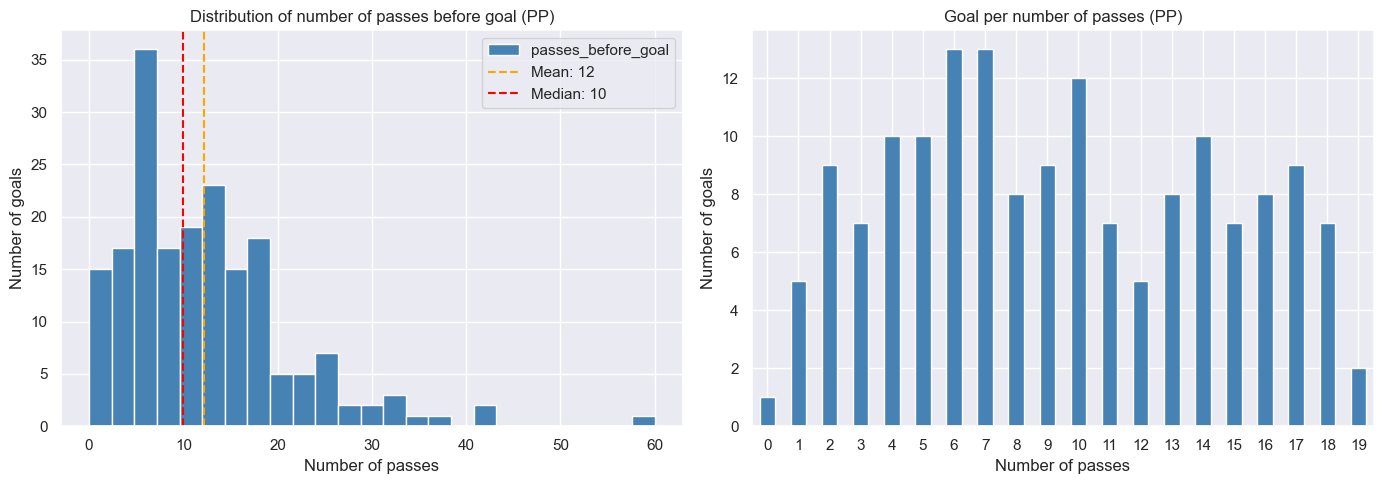

Total number of powerplays: 2461
count    189.000000
mean      12.243386
std        8.888435
min        0.000000
25%        6.000000
50%       10.000000
75%       16.000000
max       60.000000
Name: passes_before_goal, dtype: float64


In [6]:
# Plot number of passes before a goal from the beginning of a powerplay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

goal_pass_df['passes_before_goal'].plot(kind='hist', bins=25, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(goal_pass_df['passes_before_goal'].mean(), color='orange', linestyle='--', label=f"Mean: {goal_pass_df['passes_before_goal'].mean():.0f}")
axes[0].axvline(goal_pass_df['passes_before_goal'].median(), color='red', linestyle='--', label=f"Median: {goal_pass_df['passes_before_goal'].median():.0f}")
axes[0].set_title('Distribution of number of passes before goal (PP)')
axes[0].set_xlabel('Number of passes')
axes[0].set_ylabel('Number of goals')
axes[0].legend()

goal_pass_df['passes_before_goal'].value_counts().sort_index().head(20).plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Goal per number of passes (PP)')
axes[1].set_xlabel('Number of passes')
axes[1].set_ylabel('Number of goals')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"Total number of powerplays: {total_pp_seqs}")

print(goal_pass_df['passes_before_goal'].describe())

In [7]:
# Same as above but for one specific team in one specific game
team_id = 885
game_id = 7239

game_df = data[(data['teamid'] == team_id) & (data['gameid'] == game_id)].sort_values('compiledgametime').reset_index(drop=True)
pp_only = game_df[game_df['manpowersituation'] == 'powerPlay'].copy().reset_index(drop=True)

pp_only['time_gap'] = pp_only['compiledgametime'].diff()
pp_only['prev_was_goal'] = pp_only['eventname'].shift(1) == 'goal'
pp_only['prev_was_faceoff'] = pp_only['eventname'].shift(1) == 'faceoff'
pp_only['pp_start'] = (pp_only['time_gap'] > 10) | (pp_only.index == 0) | pp_only['prev_was_goal'] | pp_only['prev_was_faceoff']
pp_only['pp_seq_id'] = pp_only['pp_start'].cumsum()

num_passes_single = []
total_pp_seqs_single = 0

for seq_id, seq_df in pp_only.groupby('pp_seq_id'):
    seq_df = seq_df.reset_index(drop=True)
    total_pp_seqs_single += 1
    goal_indices = seq_df[seq_df['eventname'] == 'goal'].index
    
    for goal_index in goal_indices:
        if goal_index == 0:
            pass_count = 0
        else:
            pass_count = (seq_df.loc[:goal_index - 1, 'eventname'] == 'pass').sum()
        num_passes_single.append({
            'pp_seq_id': seq_id,
            'passes_before_goal': pass_count
        })

goal_pass_single = pd.DataFrame(num_passes_single)

print(f"Team: {team_id}, Game: {game_id}")
print(f"Total PP sequences: {total_pp_seqs_single}")
print(f"PP sequences with goal: {len(goal_pass_single)}")
print(goal_pass_single)

Team: 885, Game: 7239
Total PP sequences: 0
PP sequences with goal: 0
Empty DataFrame
Columns: []
Index: []


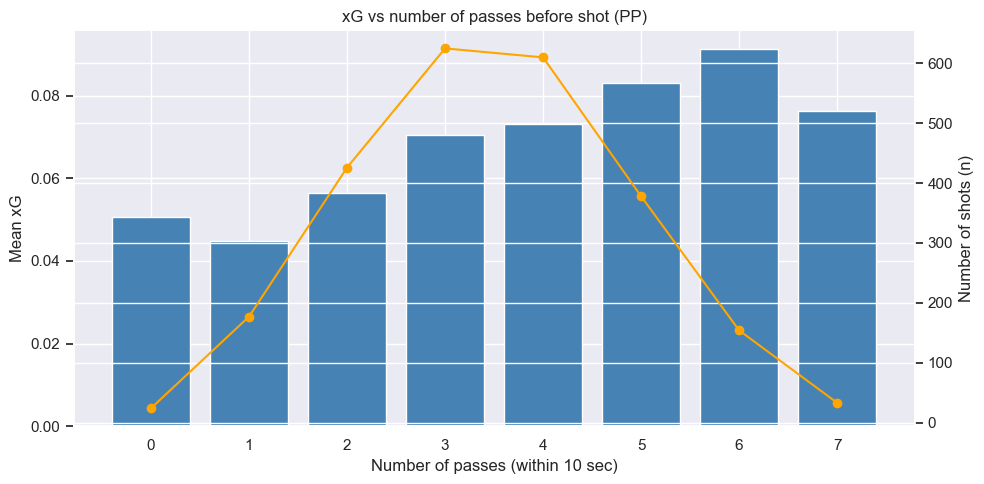

In [8]:
# Count passes within 10 seconds before each shot during the powerplay
pp_shots = data[(data['manpowersituation'] == 'powerPlay') &
                (data['eventname'].isin(['shot', 'goal']))].copy()

def count_recent_passes(row):
    mask = (data['gameid'] == row['gameid']) &\
           (data['compiledgametime'] < row['compiledgametime']) &\
           (data['compiledgametime'] > row['compiledgametime'] - 10) &\
           (data['eventname'] == 'pass') &\
           (data['manpowersituation'] == 'powerPlay')
    return mask.sum()

pp_shots['passes_before'] = pp_shots.apply(count_recent_passes, axis=1)
pp_shots.groupby('passes_before')['xg_allattempts'].agg(['mean', 'count']).head(15)

# Plot number of shots and their expected goal value against number of passes.
agg = pp_shots.groupby('passes_before')['xg_allattempts'].agg(['mean', 'count']).reset_index()
agg = agg[agg['count'] >= 10]  # Filter out low sample sizes

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(agg['passes_before'], agg['mean'], color='steelblue', label='Mean xG')
ax1.set_xlabel('Number of passes (within 10 sec)')
ax1.set_ylabel('Mean xG')
ax1.set_title('xG vs number of passes before shot (PP)')

ax2 = ax1.twinx()
ax2.plot(agg['passes_before'], agg['count'], color='orange', marker='o', label='Number of shots')
ax2.set_ylabel('Number of shots (n)')

plt.tight_layout()
plt.show()

Blue: Shots on goal by number of passes (0-7) and their mean Expected Goal value. Shot quality increases with more passes. <br>
Orange: Number of shots, most shots come after 3-4 passes. Few shots at 0-1 or 6+ passes. <br>
xG increases up to around 6 passes during the PP, then drops (only values with more than 10 observations shown).

## Optimal number of passes for goals in zone from controlled entry

In [9]:
data['eventname'].value_counts()

eventname
pass                      128975
lpr                       107131
reception                  99396
carry                      33914
controlledexit             28923
puckprotection             23417
block                      17931
faceoff                    16946
shot                       16348
controlledentry            12726
controlledentryagainst     12062
dumpout                     9367
dumpin                      8570
save                        8059
check                       7139
rebound                     4998
assist                      1394
icing                       1258
goal                         821
penalty                      804
penaltydrawn                 759
offside                      678
soshot                       140
sogoal                        41
sopuckprotection               5
Name: count, dtype: int64

In [10]:
# Team on powerplay with controlled entry
pp_entries = data[(data['manpowersituation'] == 'powerPlay') & (data['eventname'] == 'controlledentry')].copy()
print(f"Controlled entries on PP: {len(pp_entries)}")
pp_entries[['gameid', 'compiledgametime', 'period', 'eventname', 'manpowersituation']].head(10)

Controlled entries on PP: 1589


,gameid,compiledgametime,period,eventname,manpowersituation
131,72393,107.766670,1,controlledentry,powerPlay
151,72393,127.333336,1,controlledentry,powerPlay
185,72393,169.533340,1,controlledentry,powerPlay
1182,72393,1189.600000,1,controlledentry,powerPlay
1905,72393,1908.400000,2,controlledentry,powerPlay
1942,72393,1953.366700,2,controlledentry,powerPlay
1955,72393,1964.266700,2,controlledentry,powerPlay
2278,72393,2282.366700,2,controlledentry,powerPlay
2293,72393,2301.900000,2,controlledentry,powerPlay
2892,72393,2907.233400,3,controlledentry,powerPlay


In [11]:
# Create entry_id to track sequences after each controlled entry
data['is_pp_entry'] = (data['eventname'] == 'controlledentry') & (data['manpowersituation'] == 'powerPlay')
# entry_id per (game, team) so we don't mix both teams
data['entry_id'] = data.groupby(['gameid', 'teamid'])['is_pp_entry'].cumsum()

# Only keep the attacking pp team events
pp_events = data[(data['manpowersituation'] == 'powerPlay') &
                 (data['teamid'] == data['teaminpossession'])].copy()

# Look at one entry sequence
example_entry = pp_events[(pp_events['gameid'] == data['gameid'].iloc[0]) & (pp_events['entry_id'] == 1)]
example_entry[['compiledgametime', 'eventname', 'entry_id']].head(20)

,compiledgametime,eventname,entry_id
133,109.000000,pass,1
134,109.300000,reception,1
135,109.666664,shot,1
140,118.300000,lpr,1
141,122.033330,puckprotection,1
144,123.333336,lpr,1
146,125.433334,carry,1
147,126.333336,pass,1
148,127.066666,reception,1
150,127.333336,carry,1


In [12]:
# Define events that end a zone sequence
end_events = ['controlledexit', 'shot', 'goal', 'dumpout', 'turnover']

# Check what events exist in PP
pp_events = data[data['manpowersituation'] == 'powerPlay'].copy()
pp_events['eventname'].value_counts().head(20)

eventname
pass                      19474
reception                 17105
lpr                        7644
carry                      3748
shot                       2429
controlledexit             2121
controlledentry            1589
puckprotection             1546
faceoff                    1493
block                       511
assist                      368
controlledentryagainst      264
dumpin                      201
goal                        189
check                       173
save                        164
rebound                      91
offside                      47
penaltydrawn                 43
penalty                      38
Name: count, dtype: int64

In [13]:
# Events that end a zone sequence
end_events = ['controlledexit', 'dumpout', 'dumpin', 'faceoff', 'offside']

pp_events['is_end'] = pp_events['eventname'].isin(end_events)
pp_events['is_pass'] = pp_events['eventname'] == 'pass'
pp_events['is_shot'] = pp_events['eventname'].isin(['shot', 'goal'])
pp_events['is_goal'] = pp_events['eventname'] == 'goal'

example = pp_events[(pp_events['gameid'] == data['gameid'].iloc[0]) & (pp_events['entry_id'] == 1)]
example[['compiledgametime', 'eventname', 'is_pass', 'is_shot', 'is_end']].head(20)

,compiledgametime,eventname,is_pass,is_shot,is_end
131,107.766670,controlledentry,False,False,False
133,109.000000,pass,True,False,False
134,109.300000,reception,False,False,False
135,109.666664,shot,False,True,False
140,118.300000,lpr,False,False,False
141,122.033330,puckprotection,False,False,False
144,123.333336,lpr,False,False,False
145,125.433334,controlledexit,False,False,True
146,125.433334,carry,False,False,False
147,126.333336,pass,True,False,False


In [14]:
def count_passes_before_end(group):
    passes = 0
    shot_found = False
    goal_found = False
    after_shot = False

    for _, row in group.sort_values("compiledgametime").iterrows():
        if after_shot:
            # One event after shot: check if it is a goal
            if row["eventname"] == "goal":
                goal_found = True
            break
        if row["is_pass"]:
            passes += 1
        if row["eventname"] == "goal":
            shot_found = True
            goal_found = True
            break
        if row["eventname"] == "shot":
            shot_found = True
            after_shot = True  # peek at next event for goal
            continue
        if row["is_end"]:
            break

    return pd.Series({
        'passes': passes,
        'shot': shot_found,
        'goal': goal_found
    })

entry_results = pp_events.groupby(['gameid', 'teamid', 'entry_id']).apply(
    count_passes_before_end, include_groups=False
).reset_index()
entry_results = entry_results[entry_results['entry_id'] > 0]

print(f"Goals: {entry_results['goal'].sum()}")
print(f"Shots: {entry_results['shot'].sum()}")

Goals: 57
Shots: 806


In [15]:
# Passes before shot (only entries that led to shot)
shots_df = entry_results[entry_results['shot'] == True]
goals_df = entry_results[entry_results['goal'] == True]

print(f"Entries with shot: {len(shots_df)} of {len(entry_results)}")
print(f"Entries with goal: {len(goals_df)}")

print("\nPasses before shot:")
print(shots_df['passes'].describe())

print("\nPasses before goal:")
print(goals_df['passes'].describe())


Entries with shot: 806 of 1589
Entries with goal: 57

Passes before shot:
count    806.000000
mean       4.522333
std        3.660278
min        0.000000
25%        1.250000
50%        4.000000
75%        7.000000
max       22.000000
Name: passes, dtype: float64

Passes before goal:
count    57.000000
mean      4.245614
std       3.491217
min       0.000000
25%       1.000000
50%       3.000000
75%       6.000000
max      14.000000
Name: passes, dtype: float64


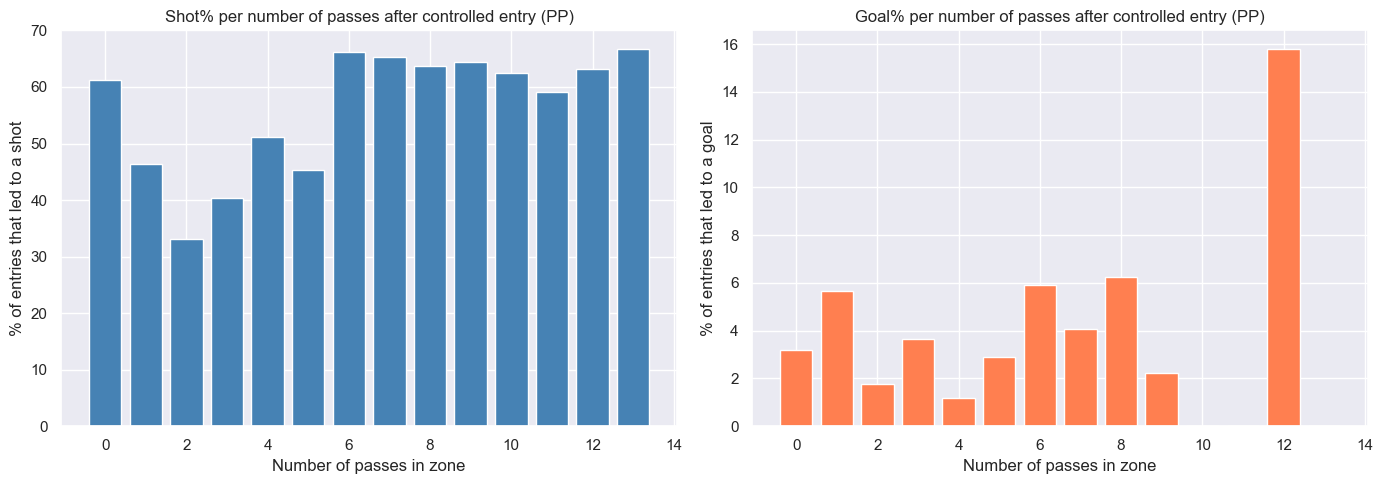

 passes  total  shots  goals  shot_pct  goal_pct
      0    157     96      5 61.146497  3.184713
      1    229    106     13 46.288210  5.676856
      2    226     75      4 33.185841  1.769912
      3    218     88      8 40.366972  3.669725
      4    168     86      2 51.190476  1.190476
      5    137     62      4 45.255474  2.919708
      6    118     78      7 66.101695  5.932203
      7     98     64      4 65.306122  4.081633
      8     80     51      5 63.750000  6.250000
      9     45     29      1 64.444444  2.222222
     10     32     20      0 62.500000  0.000000
     11     22     13      0 59.090909  0.000000
     12     19     12      3 63.157895 15.789474
     13     12      8      0 66.666667  0.000000


In [16]:
# shot% and goal% per number of passes after controlled entry
pass_stats = entry_results.groupby("passes").agg(
    total=("shot", "count"),
    shots=("shot", "sum"),
    goals=("goal", "sum")
).reset_index()
pass_stats["shot_pct"] = pass_stats["shots"] / pass_stats["total"] * 100
pass_stats["goal_pct"] = pass_stats["goals"] / pass_stats["total"] * 100
pass_stats = pass_stats[pass_stats["total"] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(pass_stats["passes"], pass_stats["shot_pct"], color="steelblue", edgecolor="white")
axes[0].set_title("Shot% per number of passes after controlled entry (PP)")
axes[0].set_xlabel("Number of passes in zone")
axes[0].set_ylabel("% of entries that led to a shot")

axes[1].bar(pass_stats["passes"], pass_stats["goal_pct"], color="coral", edgecolor="white")
axes[1].set_title("Goal% per number of passes after controlled entry (PP)")
axes[1].set_xlabel("Number of passes in zone")
axes[1].set_ylabel("% of entries that led to a goal")

plt.tight_layout()
plt.show()
print(pass_stats[["passes", "total", "shots", "goals", "shot_pct", "goal_pct"]].to_string(index=False))

Goals: 57, Shots without goal: 749


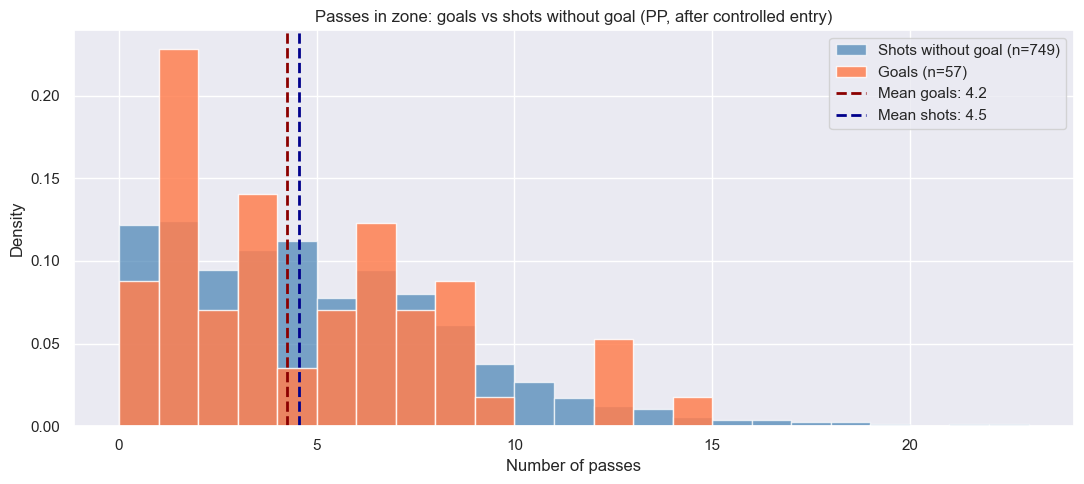

In [17]:
# Compare pass distributions: goals vs shots without goal
goals_df = entry_results[entry_results["goal"] == True]
shots_no_goal_df = entry_results[(entry_results["shot"] == True) & (entry_results["goal"] == False)]

print(f"Goals: {len(goals_df)}, Shots without goal: {len(shots_no_goal_df)}")

max_passes = int(entry_results["passes"].max()) + 2
bins = range(0, max_passes)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(shots_no_goal_df["passes"], bins=bins, density=True, alpha=0.7,
        label=f"Shots without goal (n={len(shots_no_goal_df)})", color="steelblue", edgecolor="white")
ax.hist(goals_df["passes"], bins=bins, density=True, alpha=0.85,
        label=f"Goals (n={len(goals_df)})", color="coral", edgecolor="white")
ax.axvline(goals_df["passes"].mean(), color="darkred", linestyle="--", linewidth=2,
           label=f"Mean goals: {goals_df['passes'].mean():.1f}")
ax.axvline(shots_no_goal_df["passes"].mean(), color="darkblue", linestyle="--", linewidth=2,
           label=f"Mean shots: {shots_no_goal_df['passes'].mean():.1f}")
ax.set_title("Passes in zone: goals vs shots without goal (PP, after controlled entry)")
ax.set_xlabel("Number of passes")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

entry_category  entries  shots  goals  shot_pct  goal_pct  goal_per_shot_pct
         carry     1177    594     42 50.467290  3.568394           7.070707
          pass      412    212     15 51.456311  3.640777           7.075472


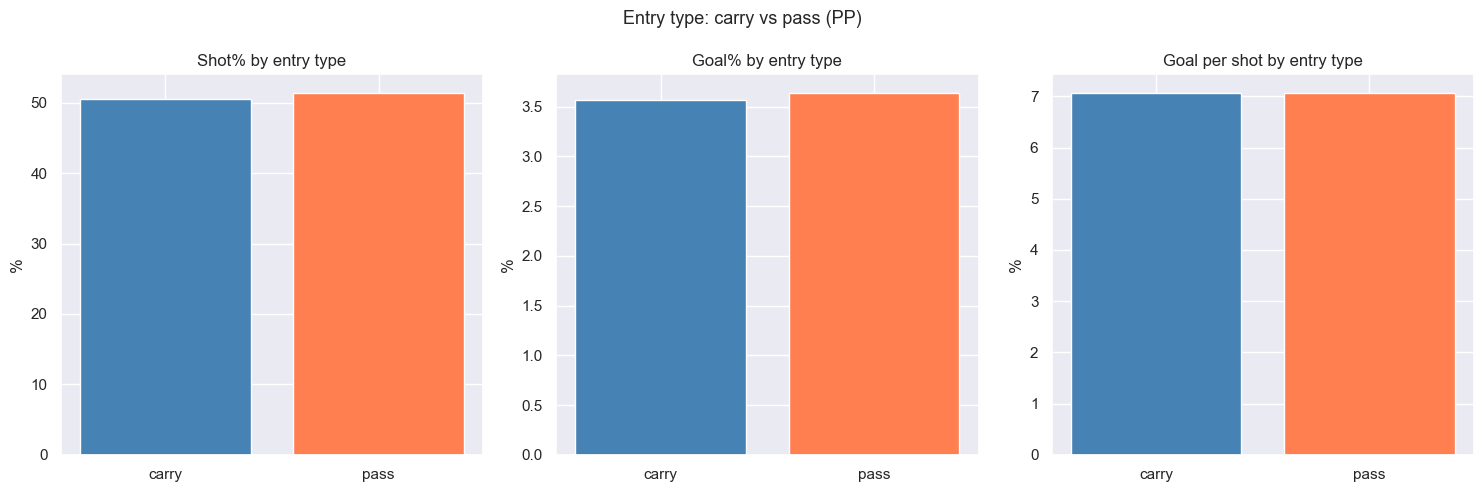

In [18]:
# Is carrying the puck in more dangerous than passing it in?
entry_types = data[data["is_pp_entry"] == True][["gameid", "teamid", "entry_id", "type"]].copy()
er_typed = entry_results.merge(entry_types, on=["gameid", "teamid", "entry_id"], how="left")

er_typed["entry_category"] = er_typed["type"].apply(
    lambda x: "carry" if str(x).startswith("carry") else ("pass" if str(x).startswith("pass") else "other")
)

type_stats = er_typed.groupby("entry_category").agg(
    entries=("shot", "count"),
    shots=("shot", "sum"),
    goals=("goal", "sum")
).reset_index()
type_stats["shot_pct"] = type_stats["shots"] / type_stats["entries"] * 100
type_stats["goal_pct"] = type_stats["goals"] / type_stats["entries"] * 100
type_stats["goal_per_shot_pct"] = type_stats["goals"] / type_stats["shots"].replace(0, float("nan")) * 100

print(type_stats.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cats = type_stats["entry_category"]
colors = ["steelblue", "coral", "mediumseagreen"]

axes[0].bar(cats, type_stats["shot_pct"], color=colors, edgecolor="white")
axes[0].set_title("Shot% by entry type")
axes[0].set_ylabel("%")

axes[1].bar(cats, type_stats["goal_pct"], color=colors, edgecolor="white")
axes[1].set_title("Goal% by entry type")
axes[1].set_ylabel("%")

axes[2].bar(cats, type_stats["goal_per_shot_pct"], color=colors, edgecolor="white")
axes[2].set_title("Goal per shot by entry type")
axes[2].set_ylabel("%")

plt.suptitle("Entry type: carry vs pass (PP)", fontsize=13)
plt.tight_layout()
plt.show()

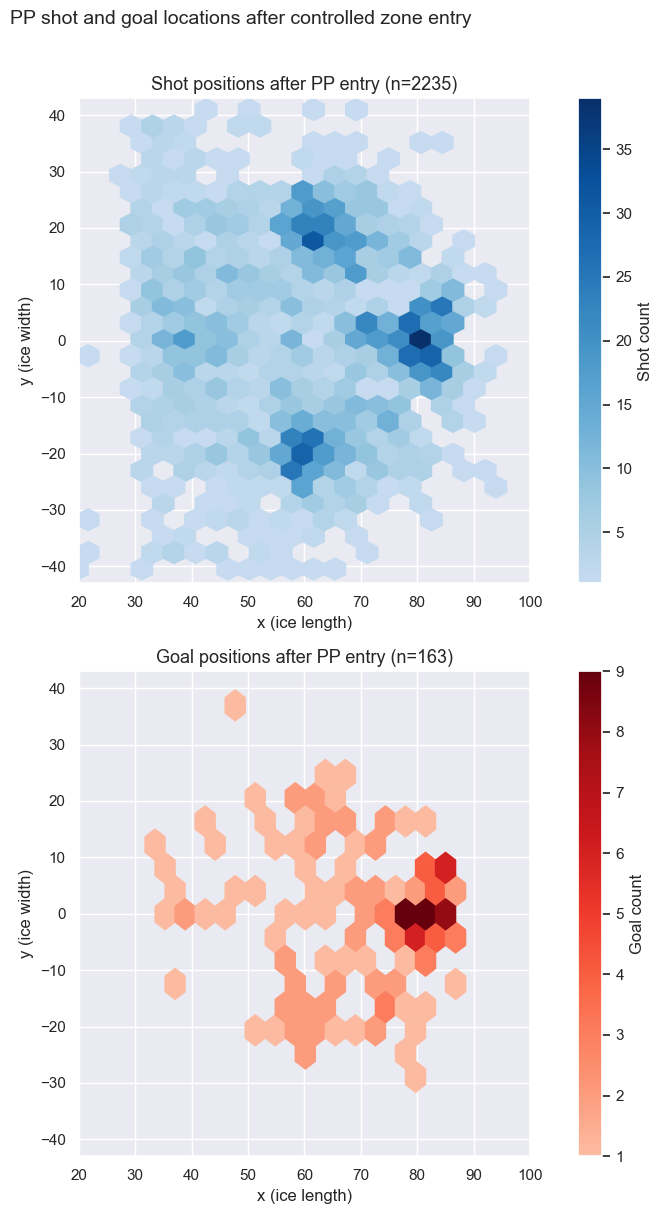

In [19]:
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

blues = LinearSegmentedColormap.from_list("blues_trim", plt.cm.Blues(np.linspace(0.25, 1.0, 256)))
reds  = LinearSegmentedColormap.from_list("reds_trim",  plt.cm.Reds(np.linspace(0.25, 1.0, 256)))

pp_entry_shots = data[
    (data["manpowersituation"] == "powerPlay") &
    (data["eventname"].isin(["shot", "goal"])) &
    (data["entry_id"] > 0) &
    (data["teamid"] == data["teaminpossession"])
].copy()

pp_entry_goals = pp_entry_shots[pp_entry_shots["eventname"] == "goal"]

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

hb0 = axes[0].hexbin(pp_entry_shots["xadjcoord"], pp_entry_shots["yadjcoord"],
                     gridsize=25, cmap=blues, mincnt=1)
axes[0].set_title(f"Shot positions after PP entry (n={len(pp_entry_shots)})", fontsize=13)
axes[0].set_xlabel("x (ice length)")
axes[0].set_ylabel("y (ice width)")
axes[0].set_xlim(20, 100)
axes[0].set_ylim(-43, 43)
axes[0].set_aspect("equal")
fig.colorbar(hb0, ax=axes[0], label="Shot count")

hb1 = axes[1].hexbin(pp_entry_goals["xadjcoord"], pp_entry_goals["yadjcoord"],
                     gridsize=15, cmap=reds, mincnt=1)
axes[1].set_title(f"Goal positions after PP entry (n={len(pp_entry_goals)})", fontsize=13)
axes[1].set_xlabel("x (ice length)")
axes[1].set_ylabel("y (ice width)")
axes[1].set_xlim(20, 100)
axes[1].set_ylim(-43, 43)
axes[1].set_aspect("equal")
fig.colorbar(hb1, ax=axes[1], label="Goal count")

plt.suptitle("PP shot and goal locations after controlled zone entry", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## PP passing zones by team

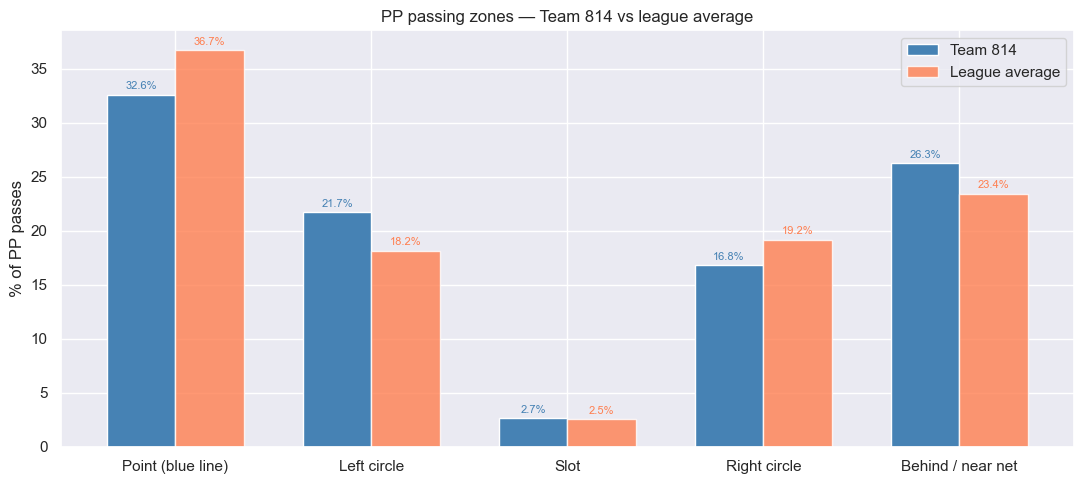

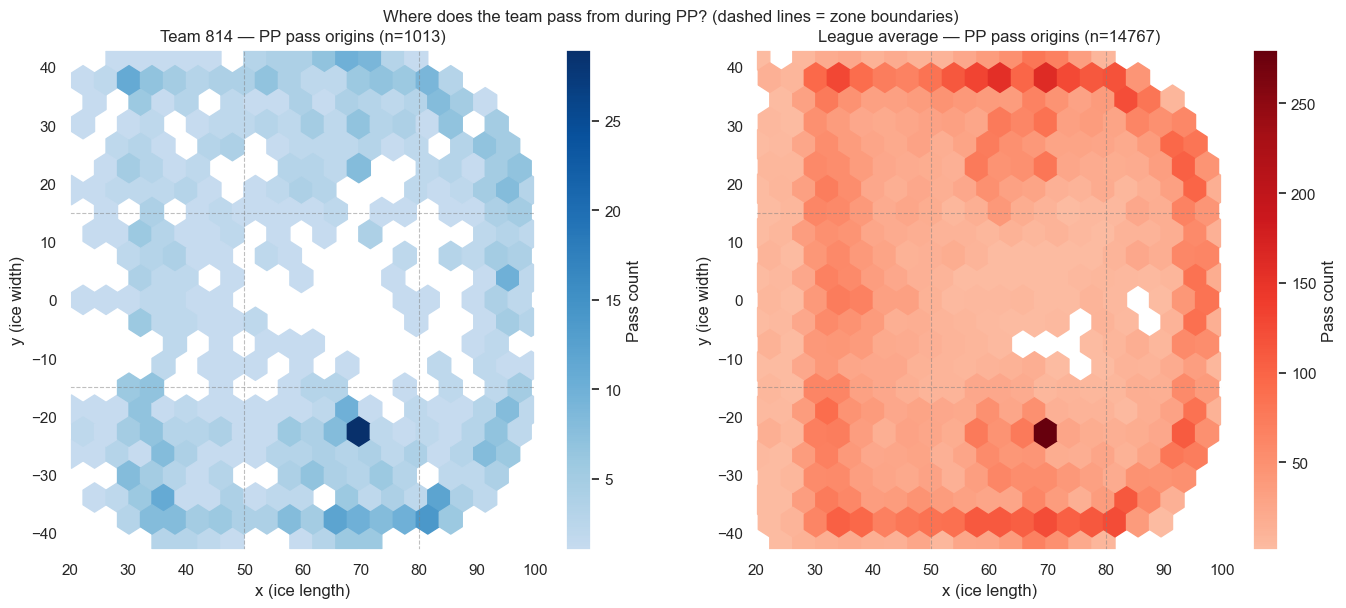


Team 814 — PP passes by zone:
zone
Point (blue line)    32.6
Left circle          21.7
Slot                  2.7
Right circle         16.8
Behind / near net    26.3

League average — PP passes by zone:
zone
Point (blue line)    36.7
Left circle          18.2
Slot                  2.5
Right circle         19.2
Behind / near net    23.4


In [20]:
team_id = data["teamid"].iloc[0] 

# PP passes for the selected team in the offensive zone (x > 20)
team_passes = data[
    (data["teamid"] == team_id) &
    (data["manpowersituation"] == "powerPlay") &
    (data["eventname"] == "pass") &
    (data["xadjcoord"] > 20)
].copy()

# League-wide PP passes for comparison
league_passes = data[
    (data["manpowersituation"] == "powerPlay") &
    (data["eventname"] == "pass") &
    (data["xadjcoord"] > 20)
].copy()

def assign_zone(row):
    x, y = row["xadjcoord"], row["yadjcoord"]
    if x < 50:                          return "Point (blue line)"
    elif x >= 80:                        return "Behind / near net"
    elif y < -15:                        return "Left circle"
    elif y > 15:                         return "Right circle"
    else:                                return "Slot"

team_passes["zone"]  = team_passes.apply(assign_zone, axis=1)
league_passes["zone"] = league_passes.apply(assign_zone, axis=1)

zone_order = ["Point (blue line)", "Left circle", "Slot", "Right circle", "Behind / near net"]

team_zone_pct  = team_passes["zone"].value_counts(normalize=True).reindex(zone_order, fill_value=0) * 100
league_zone_pct = league_passes["zone"].value_counts(normalize=True).reindex(zone_order, fill_value=0) * 100

from matplotlib.colors import LinearSegmentedColormap
import numpy as np

fig, ax = plt.subplots(figsize=(11, 5))
x_pos = np.arange(len(zone_order))
width = 0.35
ax.bar(x_pos - width/2, team_zone_pct.values, width, label=f"Team {team_id}", color="steelblue", edgecolor="white")
ax.bar(x_pos + width/2, league_zone_pct.values, width, label="League average", color="coral", edgecolor="white", alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(zone_order)
ax.set_ylabel("% of PP passes")
ax.set_title(f"PP passing zones — Team {team_id} vs league average")
ax.legend()
for i, (t, l) in enumerate(zip(team_zone_pct.values, league_zone_pct.values)):
    ax.text(i - width/2, t + 0.5, f"{t:.1f}%", ha="center", fontsize=8, color="steelblue")
    ax.text(i + width/2, l + 0.5, f"{l:.1f}%", ha="center", fontsize=8, color="coral")
plt.tight_layout()
plt.show()

blues = LinearSegmentedColormap.from_list("blues_trim", plt.cm.Blues(np.linspace(0.25, 1.0, 256)))
reds  = LinearSegmentedColormap.from_list("reds_trim",  plt.cm.Reds(np.linspace(0.25, 1.0, 256)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax in axes:
    ax.set_facecolor("white")
    ax.set_xlim(20, 100)
    ax.set_ylim(-43, 43)
    ax.set_aspect("equal")
    ax.set_xlabel("x (ice length)")
    ax.set_ylabel("y (ice width)")
    # Zone dividers
    ax.axvline(50, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(80, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axhline(15, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axhline(-15, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

hb0 = axes[0].hexbin(team_passes["xadjcoord"], team_passes["yadjcoord"],
                     gridsize=20, cmap=blues, mincnt=1)
axes[0].set_title(f"Team {team_id} — PP pass origins (n={len(team_passes)})")
fig.colorbar(hb0, ax=axes[0], label="Pass count")

hb1 = axes[1].hexbin(league_passes["xadjcoord"], league_passes["yadjcoord"],
                     gridsize=20, cmap=reds, mincnt=1)
axes[1].set_title(f"League average — PP pass origins (n={len(league_passes)})")
fig.colorbar(hb1, ax=axes[1], label="Pass count")

plt.suptitle("Where does the team pass from during PP? (dashed lines = zone boundaries)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTeam {team_id} — PP passes by zone:")
print(team_zone_pct.round(1).to_string())
print(f"\nLeague average — PP passes by zone:")
print(league_zone_pct.round(1).to_string())

## How long should a PP unit get before switching to the second unit?

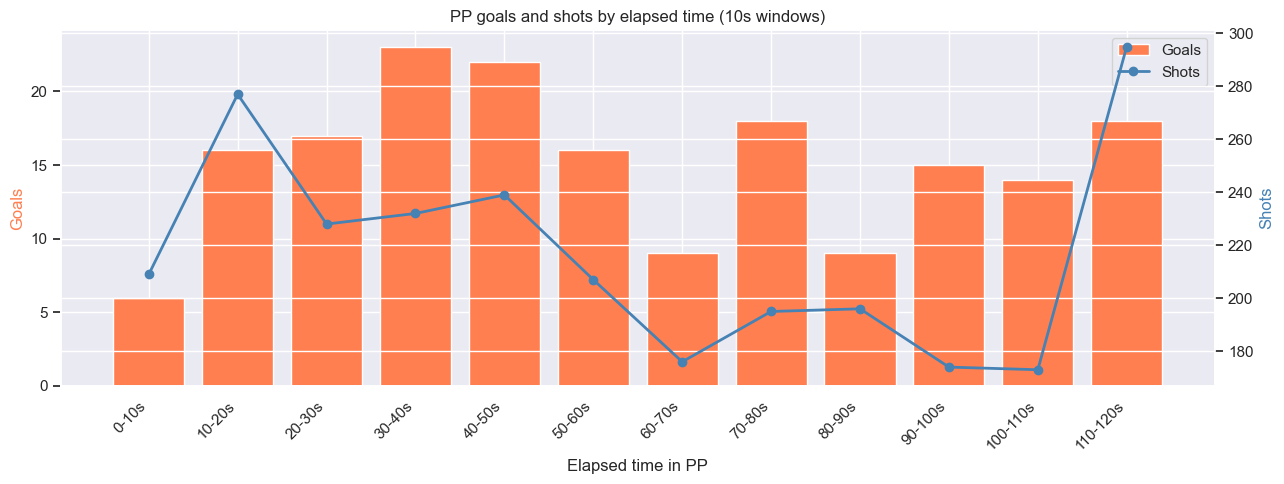

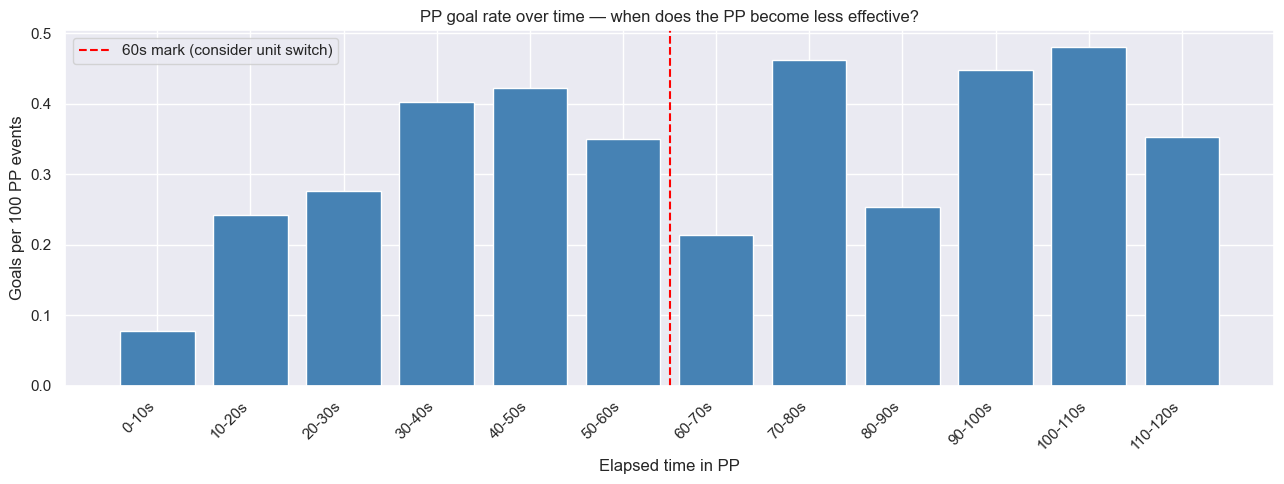

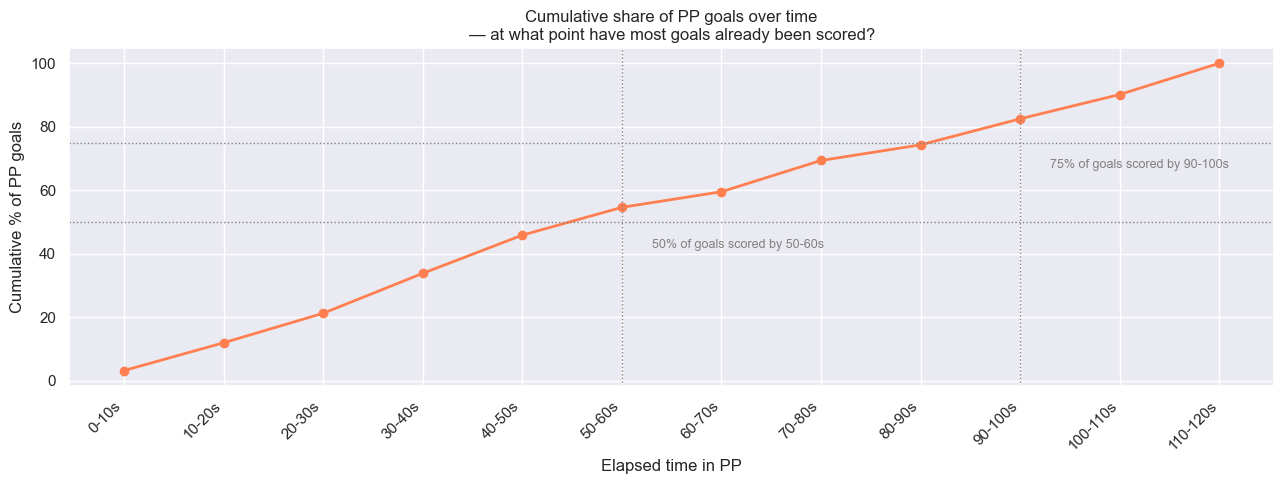

In [21]:
pp_time_rows = []

for game, game_df in data.groupby("gameid"):
    game_df = game_df.sort_values("compiledgametime")
    pp = game_df[game_df["manpowersituation"] == "powerPlay"].copy()
    if len(pp) == 0:
        continue

    pp["time_gap"] = pp["compiledgametime"].diff()
    pp["new_seq"] = (pp["time_gap"] > 10) | (pp["time_gap"].isna())
    pp["seq_id"] = pp["new_seq"].cumsum()

    for seq_id, seq in pp.groupby("seq_id"):
        seq = seq.sort_values("compiledgametime")
        start_time = seq["compiledgametime"].iloc[0]
        seq_duration = seq["compiledgametime"].iloc[-1] - start_time
        if seq_duration < 5:  # skip trivial sequences
            continue
        for _, row in seq.iterrows():
            pp_time_rows.append({
                "elapsed": row["compiledgametime"] - start_time,
                "eventname": row["eventname"],
                "is_goal": row["eventname"] == "goal",
                "is_shot": row["eventname"] in ["shot", "goal"],
            })

pp_time_df = pd.DataFrame(pp_time_rows)

# Bin elapsed time into 10-second intervals (PP is max 120s)
pp_time_df["elapsed_bin"] = (pp_time_df["elapsed"] // 10 * 10).clip(0, 110).astype(int)
pp_time_df["bin_label"] = pp_time_df["elapsed_bin"].astype(str) + "-" + (pp_time_df["elapsed_bin"] + 10).astype(str) + "s"

bin_order = [f"{i}-{i+10}s" for i in range(0, 120, 10)]

goals_by_time  = pp_time_df[pp_time_df["is_goal"]]["bin_label"].value_counts().reindex(bin_order, fill_value=0)
shots_by_time  = pp_time_df[pp_time_df["is_shot"]]["bin_label"].value_counts().reindex(bin_order, fill_value=0)
events_by_time = pp_time_df["bin_label"].value_counts().reindex(bin_order, fill_value=0)

goal_rate = (goals_by_time / events_by_time * 100).fillna(0)

fig, ax1 = plt.subplots(figsize=(13, 5))
x = range(len(bin_order))
ax1.bar(x, goals_by_time.values, color="coral", edgecolor="white", label="Goals")
ax1.set_ylabel("Goals", color="coral")
ax1.set_xticks(x)
ax1.set_xticklabels(bin_order, rotation=45, ha="right")
ax1.set_xlabel("Elapsed time in PP")

ax2 = ax1.twinx()
ax2.plot(x, shots_by_time.values, color="steelblue", marker="o", linewidth=2, label="Shots")
ax2.set_ylabel("Shots", color="steelblue")

ax1.set_title("PP goals and shots by elapsed time (10s windows)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x, goal_rate.values, color="steelblue", edgecolor="white")
ax.axvline(5.5, color="red", linestyle="--", linewidth=1.5, label="60s mark (consider unit switch)")
ax.set_xticks(x)
ax.set_xticklabels(bin_order, rotation=45, ha="right")
ax.set_xlabel("Elapsed time in PP")
ax.set_ylabel("Goals per 100 PP events")
ax.set_title("PP goal rate over time — when does the PP become less effective?")
ax.legend()
plt.tight_layout()
plt.show()

cumulative = goals_by_time.cumsum() / goals_by_time.sum() * 100
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x, cumulative.values, color="coral", marker="o", linewidth=2)
for pct, label in [(50, "50%"), (75, "75%")]:
    idx = (cumulative >= pct).idxmax()
    ix = bin_order.index(idx)
    ax.axhline(pct, color="gray", linestyle=":", linewidth=1)
    ax.axvline(ix, color="gray", linestyle=":", linewidth=1)
    ax.annotate(f"{pct}% of goals scored by {idx}", xy=(ix, pct),
                xytext=(ix + 0.3, pct - 8), fontsize=9, color="gray")
ax.set_xticks(x)
ax.set_xticklabels(bin_order, rotation=45, ha="right")
ax.set_xlabel("Elapsed time in PP")
ax.set_ylabel("Cumulative % of PP goals")
ax.set_title("Cumulative share of PP goals over time\n— at what point have most goals already been scored?")
plt.tight_layout()
plt.show()

## PP goals by period

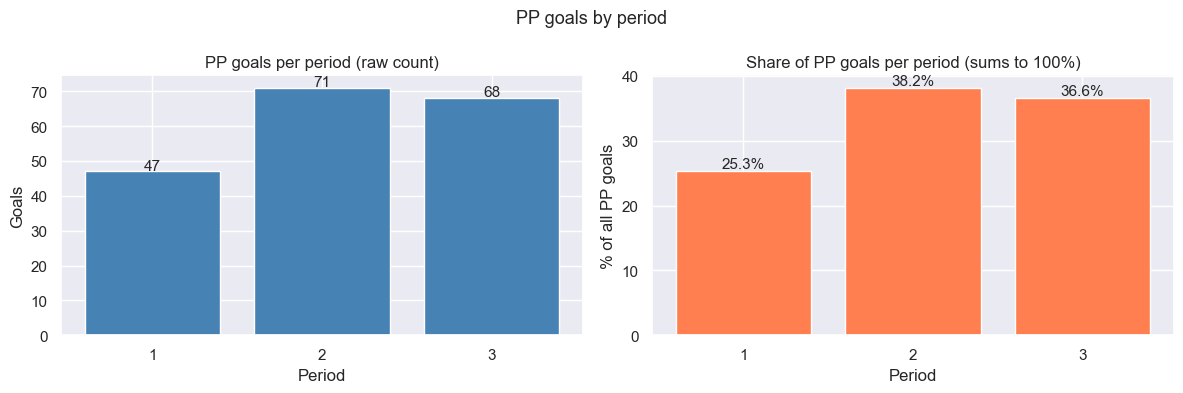

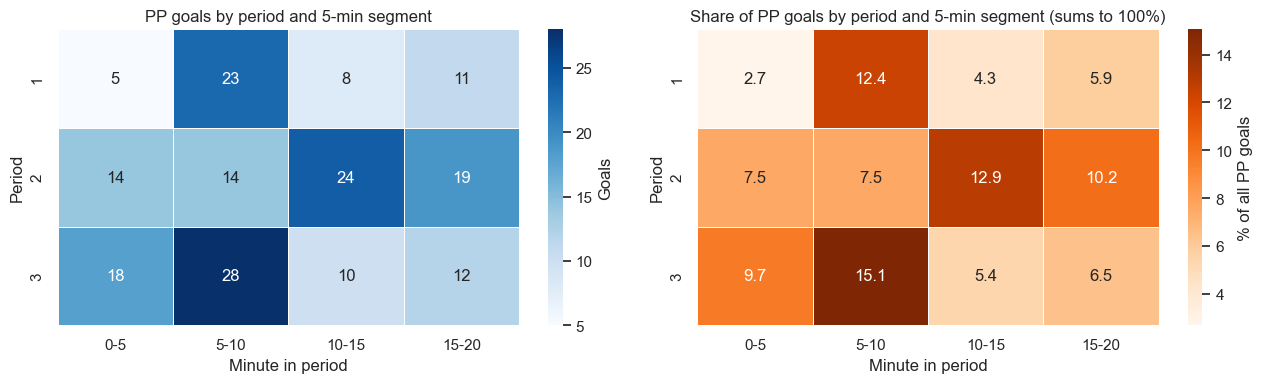

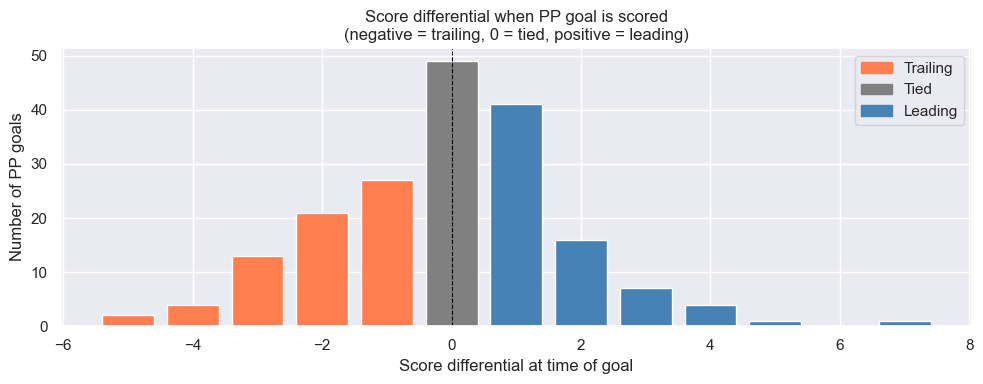

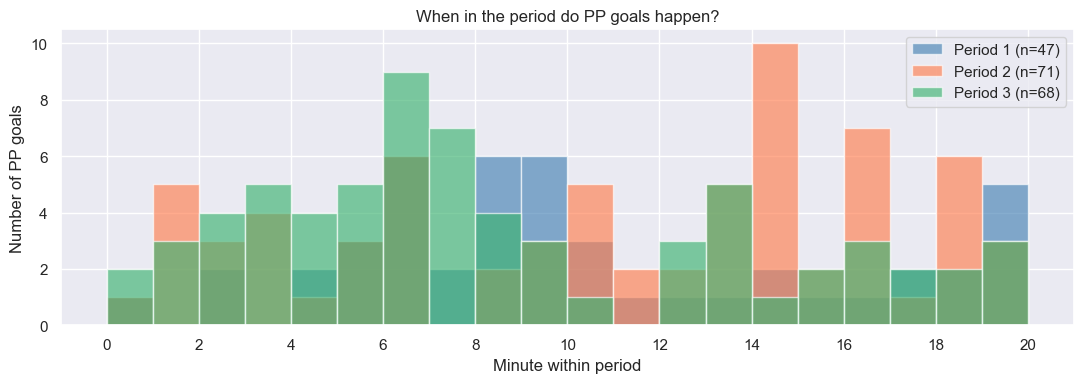

In [22]:
pp_goals = data[(data["manpowersituation"] == "powerPlay") &
                (data["eventname"] == "goal") &
                (data["period"].isin([1, 2, 3]))].copy()

pp_all = data[(data["manpowersituation"] == "powerPlay") &
              (data["period"].isin([1, 2, 3]))].copy()

# compiledgametime is cumulative across the full game
for df in [pp_goals, pp_all]:
    df["time_in_period_s"] = df["compiledgametime"] - (df["period"] - 1) * 1200
    df["minute_in_period"] = df["time_in_period_s"] / 60
    df["5min_bin"] = (df["minute_in_period"] // 5 * 5).clip(0, 15).astype(int)
    df["5min_label"] = df["5min_bin"].astype(str) + "-" + (df["5min_bin"] + 5).astype(str)

goals_per_period = pp_goals["period"].value_counts().sort_index()
share_per_period = goals_per_period / goals_per_period.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(goals_per_period.index, goals_per_period.values, color="steelblue", edgecolor="white")
axes[0].set_title("PP goals per period (raw count)")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Goals")
axes[0].set_xticks([1, 2, 3])
for i, v in zip(goals_per_period.index, goals_per_period.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=11)

axes[1].bar(share_per_period.index, share_per_period.values, color="coral", edgecolor="white")
axes[1].set_title("Share of PP goals per period (sums to 100%)")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("% of all PP goals")
axes[1].set_xticks([1, 2, 3])
for i, v in zip(share_per_period.index, share_per_period.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)

plt.suptitle("PP goals by period", fontsize=13)
plt.tight_layout()
plt.show()

bin_labels = ["0-5", "5-10", "10-15", "15-20"]
goal_matrix = pp_goals.groupby(["period", "5min_label"]).size().unstack(fill_value=0)
goal_matrix = goal_matrix.reindex(columns=bin_labels, fill_value=0)

event_matrix = pp_all.groupby(["period", "5min_label"]).size().unstack(fill_value=0)
event_matrix = event_matrix.reindex(columns=bin_labels, fill_value=0)
share_matrix = (goal_matrix / goal_matrix.values.sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(goal_matrix, annot=True, fmt="d", cmap="Blues",
            ax=axes[0], linewidths=0.5, cbar_kws={"label": "Goals"})
axes[0].set_title("PP goals by period and 5-min segment")
axes[0].set_xlabel("Minute in period")
axes[0].set_ylabel("Period")

sns.heatmap(share_matrix, annot=True, fmt=".1f", cmap="Oranges",
            ax=axes[1], linewidths=0.5, cbar_kws={"label": "% of all PP goals"})
axes[1].set_title("Share of PP goals by period and 5-min segment (sums to 100%)")
axes[1].set_xlabel("Minute in period")
axes[1].set_ylabel("Period")

plt.tight_layout()
plt.show()

score_counts = pp_goals["scoredifferential"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["coral" if x < 0 else "steelblue" if x > 0 else "gray" for x in score_counts.index]
ax.bar(score_counts.index, score_counts.values, color=colors, edgecolor="white")
ax.set_title("Score differential when PP goal is scored\n(negative = trailing, 0 = tied, positive = leading)")
ax.set_xlabel("Score differential at time of goal")
ax.set_ylabel("Number of PP goals")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="coral", label="Trailing"),
    Patch(color="gray", label="Tied"),
    Patch(color="steelblue", label="Leading")
])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
period_colors = {1: "steelblue", 2: "coral", 3: "mediumseagreen"}
for p in [1, 2, 3]:
    subset = pp_goals[pp_goals["period"] == p]["minute_in_period"]
    ax.hist(subset, bins=20, range=(0, 20), alpha=0.65,
            label=f"Period {p} (n={len(subset)})", color=period_colors[p], edgecolor="white")
ax.set_title("When in the period do PP goals happen?")
ax.set_xlabel("Minute within period")
ax.set_ylabel("Number of PP goals")
ax.set_xticks(range(0, 21, 2))
ax.legend()
plt.tight_layout()
plt.show()

## PP conversion rate by score differention

 score_diff  sequences  goals  conversion_pct
         -4         14      4       28.571429
         -3         38     11       28.947368
         -2        106     22       20.754717
         -1        174     27       15.517241
          0        323     53       16.408669
          1        166     39       23.493976
          2         88     16       18.181818
          3         30      5       16.666667
          4          8      3       37.500000


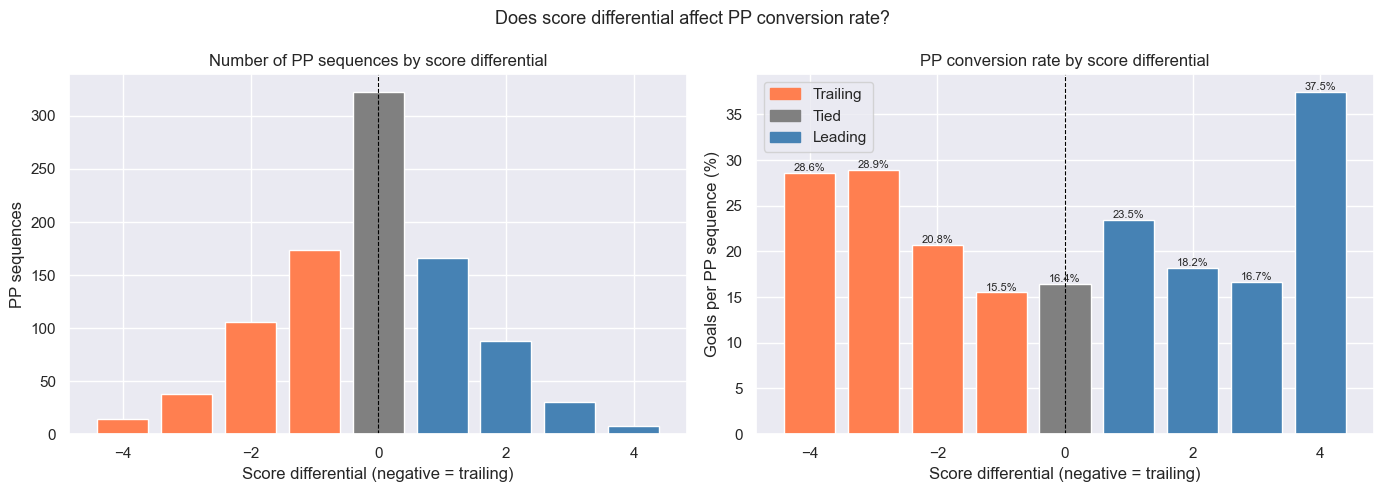

In [ ]:
pp_seq_rows = []

for game, game_df in data.groupby("gameid"):
    game_df = game_df.sort_values("compiledgametime")
    pp = game_df[game_df["manpowersituation"] == "powerPlay"].copy()
    if len(pp) == 0:
        continue

    pp["time_gap"] = pp["compiledgametime"].diff()
    pp["new_seq"] = (pp["time_gap"] > 10) | (pp["time_gap"].isna())
    pp["seq_id"] = pp["new_seq"].cumsum()

    for seq_id, seq in pp.groupby("seq_id"):
        seq = seq.sort_values("compiledgametime")
        if len(seq) < 3:
            continue
        pp_seq_rows.append({
            "score_diff": seq["scoredifferential"].iloc[0],
            "goal": (seq["eventname"] == "goal").any(),
            "shots": seq["eventname"].isin(["shot", "goal"]).sum(),
        })

pp_seq_df = pd.DataFrame(pp_seq_rows)

# Focus on realistic score differentials
pp_seq_df = pp_seq_df[pp_seq_df["score_diff"].between(-4, 4)]

conv = pp_seq_df.groupby("score_diff").agg(
    sequences=("goal", "count"),
    goals=("goal", "sum")
).reset_index()
conv["conversion_pct"] = conv["goals"] / conv["sequences"] * 100

print(conv.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# red = trailing, gray = tied, blue = leading
colors = ["coral" if x < 0 else "steelblue" if x > 0 else "gray"
          for x in conv["score_diff"]]

axes[0].bar(conv["score_diff"], conv["sequences"], color=colors, edgecolor="white")
axes[0].set_title("Number of PP sequences by score differential")
axes[0].set_xlabel("Score differential (negative = trailing)")
axes[0].set_ylabel("PP sequences")
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")

axes[1].bar(conv["score_diff"], conv["conversion_pct"], color=colors, edgecolor="white")
for _, row in conv.iterrows():
    axes[1].text(row["score_diff"], row["conversion_pct"] + 0.2,
                 f"{row['conversion_pct']:.1f}%", ha="center", fontsize=8)
axes[1].set_title("PP conversion rate by score differential")
axes[1].set_xlabel("Score differential (negative = trailing)")
axes[1].set_ylabel("Goals per PP sequence (%)")
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")

from matplotlib.patches import Patch
legend = [
    Patch(color="coral", label="Trailing"),
    Patch(color="gray", label="Tied"),
    Patch(color="steelblue", label="Leading"),
]
axes[1].legend(handles=legend)

plt.suptitle("Does score differential affect PP conversion rate?", fontsize=13)
plt.tight_layout()
plt.show()